In [7]:
   import sys
   print(sys.version)
   print(sys.executable)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
c:\Projects\churn-platform\venv\Scripts\python.exe


In [8]:
import sys
sys.path.insert(0, "..")   # lets the notebook see the churn package in the project root

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from churn.features import load_customers

sns.set_theme(style="whitegrid")
df = load_customers()
print(df.shape)
print(df.isna().sum())                        # missing values
print(df["churn"].value_counts(normalize=True))  # churn ratio

(7043, 21)
customer_id           0
gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
churn                 0
dtype: int64
churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


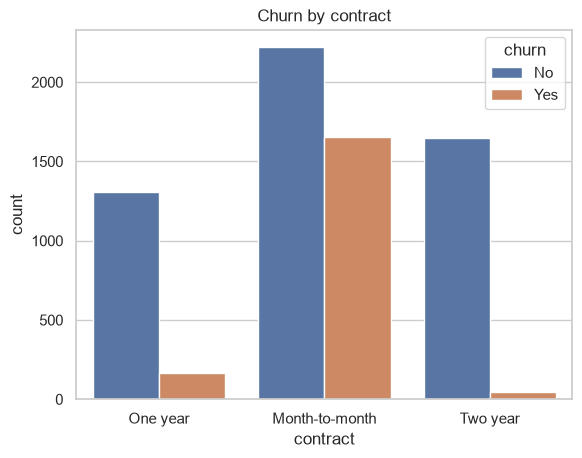

In [9]:
sns.countplot(data=df, x="contract", hue="churn")
plt.title("Churn by contract")
plt.show()

Contract: month-to-month customers churn at 42.7%, versus 11.3% on one-year and 2.8% on two-year contracts. These three numbers are already confirmed from your SQL and dashboard.

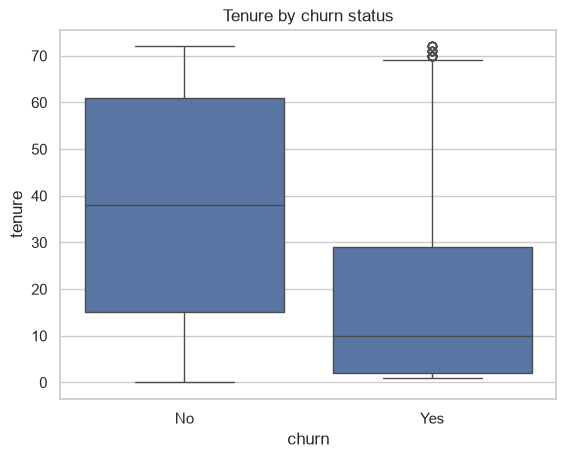

In [10]:
sns.boxplot(data=df, x="churn", y="tenure")
plt.title("Tenure by churn status")
plt.show()

Tenure: compare the median line for churned and retained customers. Customers who churn usually have a much lower median tenure, and your dashboard shows churn falling from about 48% in months 0-11 to about 9.5% after 48 months.

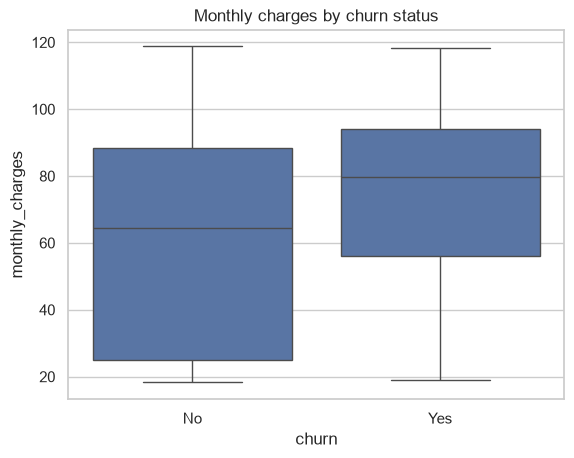

In [11]:
sns.boxplot(data=df, x="churn", y="monthly_charges")
plt.title("Monthly charges by churn status")
plt.show()

Monthly charges: look at whether the "Yes" box sits higher than the "No" box. In this dataset churners usually pay more per month.

In [12]:
rate = (df.groupby("payment_method")["churn"]
          .apply(lambda s: (s == "Yes").mean())
          .sort_values())
print(rate.round(3))

payment_method
Credit card (automatic)      0.152
Bank transfer (automatic)    0.167
Mailed check                 0.191
Electronic check             0.453
Name: churn, dtype: float64


Payment method: the printed table is sorted from lowest to highest churn. State which method is highest and which is lowest, using your numbers.